# DNV-RP-F104 CO2 pipeline transport-envelope screening

This example uses NeqSim's edition-aware `DnvRpF104Co2PipelineEnvelopeScreeningKernel` for the current `DNV-RP-F104 2021-02+AMD:2021-09` basis. It compares a verified project composition and ordered operating profile with caller-controlled composition limits, MAOP, design temperatures, and externally derived composition-specific single-phase pressure boundaries.

> **Boundary:** this is a regression-backed `SCREENING` calculation, not DNV conformity. The specifications, EOS/property validation, phase boundaries and their uncertainty, hydraulic/thermal cases, pressure-temperature limits, materials/corrosion/fracture basis, construction, safety, operation, requalification, and approvals remain external. DNV-ST-F101 structural design is not replaced.

In [1]:
from pathlib import Path
import os
import sys
import jpype

ROOT = Path.cwd().resolve()
while not (ROOT / 'pom.xml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
assert (ROOT / 'pom.xml').exists(), 'Run this notebook from the NeqSim repository tree'

if not jpype.isJVMStarted():
    local_classpath = os.environ.get('NEQSIM_NOTEBOOK_CLASSPATH')
    if local_classpath:
        jpype.startJVM(classpath=local_classpath.split(os.pathsep), convertStrings=True)
    else:
        sys.path.insert(0, str(ROOT / 'devtools'))
        from neqsim_dev_setup import neqsim_init
        neqsim_init(project_root=ROOT, recompile=not (ROOT / 'target/classes').exists(), verbose=False)

from jpype import JClass
import pandas as pd
import matplotlib.pyplot as plt
print('Workspace kernel loaded:', ROOT)

mkdir -p failed for path /root/.config/matplotlib: [Errno 30] Read-only file system: '/root/.config'
Matplotlib created a temporary cache directory at /tmp/matplotlib-g8wejtf5 because there was an issue with the default path ({configdir}); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.
Workspace kernel loaded: /workspace/scratch/de313162ffce/repo_f104


## 1. Verified demonstration basis

The numerical values below are project-controlled demonstration inputs, not F104 limits. Each pressure boundary would be derived from the actual bounded composition using a validated EOS and controlled uncertainty method. The evidence flags attest that the underlying records were reviewed; the flags are not the evidence.

In [2]:
StandardType = JClass('neqsim.process.mechanicaldesign.designstandards.StandardType')
StandardEdition = JClass('neqsim.process.mechanicaldesign.designstandards.StandardEdition')
Kernel = JClass('neqsim.process.engineering.calculation.DnvRpF104Co2PipelineEnvelopeScreeningKernel')
Input = JClass('neqsim.process.engineering.calculation.DnvRpF104Co2PipelineEnvelopeScreeningKernel$Input')
OperatingPoint = JClass('neqsim.process.engineering.calculation.DnvRpF104Co2PipelineEnvelopeScreeningKernel$OperatingPoint')

edition = StandardEdition.defaultEdition(StandardType.DNV_RP_F104)
kernel = Kernel()
nominal_profile = [
    ('inlet', 0.0, 14.0e6, 293.15, 10.0e6),
    ('midline', 50_000.0, 12.0e6, 288.15, 9.0e6),
    ('outlet', 100_000.0, 10.5e6, 283.0, 9.5e6),
]

def run_screen(profile=nominal_profile, thermodynamic_evidence=True):
    builder = (Input.builder(edition, 'Pipeline')
        .co2MoleFraction(0.98)
        .minimumCo2MoleFraction(0.97)
        .waterMoleFraction(0.0001)
        .maximumWaterMoleFraction(0.0002)
        .otherImpuritiesWithinProjectSpecification(True)
        .designMinimumTemperatureK(273.15)
        .designMaximumTemperatureK(323.15)
        .maximumAllowableOperatingPressurePaAbsolute(15.0e6)
        .co2PipelineApplicabilityVerified(True)
        .compositionAndSpecificationVerified(True)
        .thermodynamicModelVerified(thermodynamic_evidence)
        .singlePhaseBoundaryInterpretationVerified(True)
        .operatingProfileVerified(True)
        .pressureTemperatureLimitsVerified(True)
        .materialsCorrosionAndFractureBasisVerified(True)
        .safetyConstructionOperationsAndRequalificationReviewed(True))
    for point in profile:
        builder.addOperatingPoint(OperatingPoint(*point))
    return kernel.calculate(builder.build(), None)

result = run_screen()
assessment = result.getValue()
summary = pd.Series({
    'status': str(result.getStatus()),
    'edition': str(assessment.getStandardEdition()),
    'CO2 mole-fraction margin [-]': float(assessment.getCo2MoleFractionMargin()),
    'water mole-fraction margin [-]': float(assessment.getWaterMoleFractionMargin()),
    'minimum single-phase pressure margin [MPa]': float(assessment.getMinimumSinglePhasePressureMarginPa()) / 1e6,
    'minimum MAOP margin [MPa]': float(assessment.getMinimumMaximumAllowableOperatingPressureMarginPa()) / 1e6,
    'minimum low-temperature margin [K]': float(assessment.getMinimumLowTemperatureMarginK()),
    'all caller-controlled constraints satisfied': bool(assessment.allConstraintsSatisfied()),
    'engineering approval required': bool(assessment.toMap().get('engineeringApprovalRequired')),
})
assert str(result.getStatus()) == 'CALCULATED_REVIEW_REQUIRED'
assert abs(float(assessment.getMinimumSinglePhasePressureMarginPa()) - 1.0e6) < 1e-9
assert bool(assessment.allConstraintsSatisfied())
summary.to_frame('screening result')

,screening result
status,CALCULATED_REVIEW_REQUIRED
edition,DNV-RP-F104 2021-02+AMD:2021-09
CO2 mole-fraction margin [-],0.01
water mole-fraction margin [-],0.0001
minimum single-phase pressure margin [MPa],1.0
minimum MAOP margin [MPa],1.0
minimum low-temperature margin [K],9.85
all caller-controlled constraints satisfied,True
engineering approval required,True


## 2. Pressure profile and caller-controlled boundaries

The chart shows the hydraulic pressure profile, the separately supplied composition-specific minimum single-phase pressure boundary, and the externally established MAOP. It visualizes only the implemented margin identities.

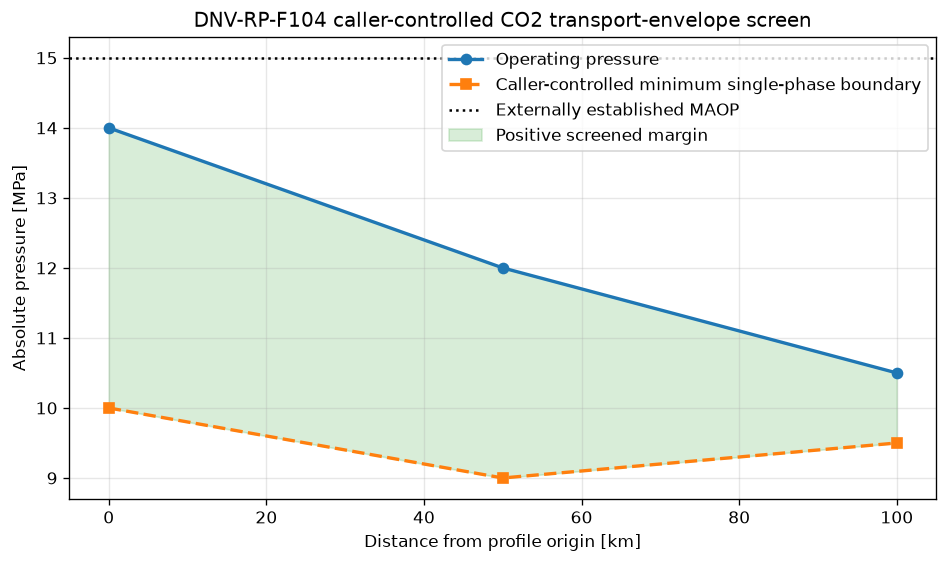

,label,distance [km],operating pressure [MPa abs],minimum single-phase boundary [MPa abs],phase-boundary margin [MPa]
0,inlet,0.0,14.0,10.0,4.0
1,midline,50.0,12.0,9.0,3.0
2,outlet,100.0,10.5,9.5,1.0


In [3]:
profile_rows = [{
    'label': str(point.getLabel()),
    'distance [km]': float(point.getDistanceM()) / 1000.0,
    'operating pressure [MPa abs]': float(point.getPressurePaAbsolute()) / 1e6,
    'minimum single-phase boundary [MPa abs]': float(point.getCallerControlledMinimumSinglePhasePressurePaAbsolute()) / 1e6,
    'phase-boundary margin [MPa]': float(point.getSinglePhasePressureMarginPa()) / 1e6,
} for point in assessment.getOperatingPoints()]
profile_table = pd.DataFrame(profile_rows)

fig, ax = plt.subplots(figsize=(8, 4.8))
x = profile_table['distance [km]']
operating = profile_table['operating pressure [MPa abs]']
boundary = profile_table['minimum single-phase boundary [MPa abs]']
ax.plot(x, operating, marker='o', linewidth=2, label='Operating pressure')
ax.plot(x, boundary, marker='s', linestyle='--', linewidth=2, label='Caller-controlled minimum single-phase boundary')
ax.axhline(15.0, color='black', linestyle=':', linewidth=1.5, label='Externally established MAOP')
ax.fill_between(x, boundary, operating, where=operating >= boundary, alpha=0.18, color='tab:green', label='Positive screened margin')
ax.set_xlabel('Distance from profile origin [km]')
ax.set_ylabel('Absolute pressure [MPa]')
ax.set_title('DNV-RP-F104 caller-controlled CO2 transport-envelope screen')
ax.grid(True, alpha=0.3)
ax.legend(loc='best')
fig.tight_layout()
assert (profile_table['phase-boundary margin [MPa]'] >= 0.0).all()
plt.show()
profile_table

**Figure discussion.** The demonstration operating pressure declines from 14.0 MPa absolute at the inlet to 10.5 MPa at 100 km, while the supplied boundary varies from 10.0 to 9.5 MPa. The minimum screened phase-boundary margin is 1.0 MPa at the outlet and the minimum MAOP margin is 1.0 MPa at the inlet. The changing boundary illustrates why a pure-CO2 critical pressure or one constant cricondenbar is not a defensible substitute for a composition- and temperature-specific project basis. Recalculate the phase boundary and hydraulic/thermal profile for every governed composition and operating/transient case, including uncertainty, before design approval.

## 3. A negative margin remains visible

A verified profile that falls below its supplied boundary is still calculated. This separates input/evidence readiness from the engineering finding and prevents a failed constraint from being hidden as a generic execution error.

In [4]:
outside_profile = [
    ('inlet', 0.0, 14.0e6, 293.15, 10.0e6),
    ('outlet', 100_000.0, 8.0e6, 283.0, 9.5e6),
]
outside = run_screen(profile=outside_profile)
outside_assessment = outside.getValue()
finding = pd.Series({
    'status': str(outside.getStatus()),
    'minimum single-phase pressure margin [MPa]': float(outside_assessment.getMinimumSinglePhasePressureMarginPa()) / 1e6,
    'all caller-controlled constraints satisfied': bool(outside_assessment.allConstraintsSatisfied()),
    'interpretation': 'Calculated screening finding; engineering review and project action required',
})
assert str(outside.getStatus()) == 'CALCULATED_REVIEW_REQUIRED'
assert abs(float(outside_assessment.getMinimumSinglePhasePressureMarginPa()) + 1.5e6) < 1e-9
assert not bool(outside_assessment.allConstraintsSatisfied())
finding.to_frame('below-boundary case')

,below-boundary case
status,CALCULATED_REVIEW_REQUIRED
minimum single-phase pressure margin [MPa],-1.5
all caller-controlled constraints satisfied,False
interpretation,Calculated screening finding; engineering revi...


## 4. Fail closed when thermodynamic evidence is missing

Numeric boundaries are not self-validating. The same values are blocked when the composition-specific thermodynamic-model evidence flag is false. Retain the EOS choice, interaction parameters, validation data, phase-envelope calculation, uncertainty treatment, and accountable review beside the screen.

In [5]:
blocked = run_screen(thermodynamic_evidence=False)
findings = pd.DataFrame([{
    'code': str(item.toMap().get('code')),
    'severity': 'BLOCKER',
    'message': str(item.toMap().get('message')),
} for item in blocked.getReadiness().getBlockers()])
assert str(blocked.getStatus()) == 'BLOCKED'
assert blocked.getValue() is None
assert 'DNV_RP_F104_THERMODYNAMICS_NOT_VERIFIED' in set(findings['code'])
findings

,code,severity,message
0,DNV_RP_F104_THERMODYNAMICS_NOT_VERIFIED,BLOCKER,The composition-specific thermodynamic model h...
